# Análise de Stemming — CETENFolha

Experimento de stemming aplicado ao corpus CETENFolha-1.0, comparando os algoritmos
PorterStemmer, SnowballStemmer (português) e RSLPStemmer sobre os 100 primeiros artigos.

In [89]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.stem import *
from nltk.stem import SnowballStemmer
from collections import Counter

## 1. Teste com PorterStemmer (Inglês)

Validação do ambiente usando o PorterStemmer sobre palavras em inglês.
Este algoritmo não é adequado para português, sendo usado aqui apenas como referência.

In [91]:
testStemmer = PorterStemmer()

In [92]:
plurals = ['caresses', 'flies', 'dies', 'mules', 'denied', 'died', 'agreed', 'owned', 'humbled', 'sized', 'meeting', 'stating', 'siezing', 'itemization', 'sensational', 'traditional', 'reference', 'colonizer', 'plotted']

In [93]:
singles = [testStemmer.stem(plural) for plural in plurals]

In [94]:
print(' '.join(singles))

caress fli die mule deni die agre own humbl size meet state siez item sensat tradit refer colon plot


## 2. SnowballStemmer para Português

Definição do stemmer principal e das funções auxiliares que serão aplicadas ao dataset.
O SnowballStemmer é baseado no algoritmo de Paice/Husk, com suporte nativo ao português.

In [95]:
stemmer = SnowballStemmer('portuguese')

In [96]:
def applyStemming(text):
    return " ".join(stemmer.stem(word) for word in str(text).split())

def applyStemmingToDataset(dataset, inColumn, outColumn="stemmedText"):
    dataset[outColumn] = dataset[inColumn].astype(str).apply(applyStemming)
    return dataset

## 3. Carregamento do Dataset

Leitura do corpus CETENFolha pré-processado (100 artigos, sem tags XML, codificado em UTF-8)
e aplicação do SnowballStemmer sobre cada linha de texto.

In [97]:
with open('dataset/CETENFolha-100artigos.txt', 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]

df = pd.DataFrame(lines, columns=['text'])
df.head()

,text
0,PT no governo
1,Gilberto Dimenstein
2,BRASÍLIA Pesquisa Datafolha publicada hoje rev...
3,"Tem sentido -- aliás, muitíssimo sentido ."
4,"Muito mais do que nos tempos na ditadura, a so..."


In [98]:
df = applyStemmingToDataset(df, 'text')
df.head()

,text,stemmedText
0,PT no governo,pt no govern
1,Gilberto Dimenstein,gilbert dimenstein
2,BRASÍLIA Pesquisa Datafolha publicada hoje rev...,brasíl pesquis datafolh public hoj revel um da...
3,"Tem sentido -- aliás, muitíssimo sentido .","tem sent -- aliás, muitíssim sent ."
4,"Muito mais do que nos tempos na ditadura, a so...","muit mais do que nos temp na ditadura, a solid..."


## 4. Frequência de Stems — SnowballStemmer

Contagem das stems geradas pelo Snowball. As mais frequentes tendem a ser stopwords e
preposições, que não foram removidas do corpus nesta etapa.

In [99]:
all_stems = ' '.join(df['stemmedText']).split()
stem_counts = Counter(all_stems)

top10 = stem_counts.most_common(10)

print ("=== Top 10 Stems ===")
for stem, count in top10:
    print(f"{stem}: {count}")

=== Top 10 Stems ===
.: 336
de: 305
o: 226
a: 213
que: 137
do: 134
e: 124
da: 102
em: 79
par: 72


## 5. RSLPStemmer

O RSLP (Removedor de Sufixos da Língua Portuguesa) é um algoritmo desenvolvido
especificamente para o português brasileiro. Aplicado ao mesmo corpus para comparação.

In [100]:
rslp = RSLPStemmer()

df['stem_rslp'] = df['text'].astype(str).apply(
    lambda text: ' '.join(rslp.stem(w) for w in text.split())
)

all_stems_rslp = ' '.join(df['stem_rslp']).split()
stem_counts_rslp = Counter(all_stems_rslp)

top10_rslp = stem_counts_rslp.most_common(10)

print ("=== Top 10 RSLP Stems ===")
for stem, count in top10_rslp:
    print(f"{stem}: {count}")

=== Top 10 RSLP Stems ===
.: 336
de: 305
o: 226
a: 213
do: 174
que: 137
da: 129
e: 124
em: 79
no: 74


In [101]:
snowball = SnowballStemmer('portuguese')
rslp = RSLPStemmer()

unique_words = set(' '.join(df['text']).split())

## 6. Comparação entre Snowball e RSLP

Identificação das divergências entre os dois algoritmos sobre o vocabulário do corpus.
Diferenças evidenciam as estratégias distintas de cada abordagem: o RSLP tende a ser
mais agressivo na remoção de sufixos em português.

In [102]:
differences = [
    (word, snowball.stem(word), rslp.stem(word))
    for word in unique_words
    if snowball.stem(word) != rslp.stem(word)
]

print(f"Total de palavras únicas: {len(unique_words)}")
print(f"Divergências entre Snowball e RSLP: {len(differences)}")
print(f"\n{'Palavra':<20} {'Snowball':<20} {'RSLP':<20}")
print("-" * 60)
for word, s, r in sorted(differences)[:30]:
    print(f"{word:<20} {s:<20} {r:<20}")


Total de palavras únicas: 3209
Divergências entre Snowball e RSLP: 660

Palavra              Snowball             RSLP                
------------------------------------------------------------
'técnica             'técnic              'técn               
(Fundação            (fundaçã             (fund               
(Serviço             (servic              (serviç             
(agora               (agor                (ag                 
(editora             (editor              (edi                
(«Nem                («nem                («n                 
AMERICANO            american             americ              
ARTES                artes                art                 
Abreu                abreu                abr                 
Adolescente          adolescent           adolesc             
Airbus               airbus               airbu               
Algo                 algo                 alg                 
Alto                 alto                 alt   

## 7. Distribuição de Frequência

Visualização da distribuição das stems seguindo a Lei de Zipf: poucas stems concentram
a maior parte das ocorrências, enquanto a grande maioria aparece raramente (hapax legomena).

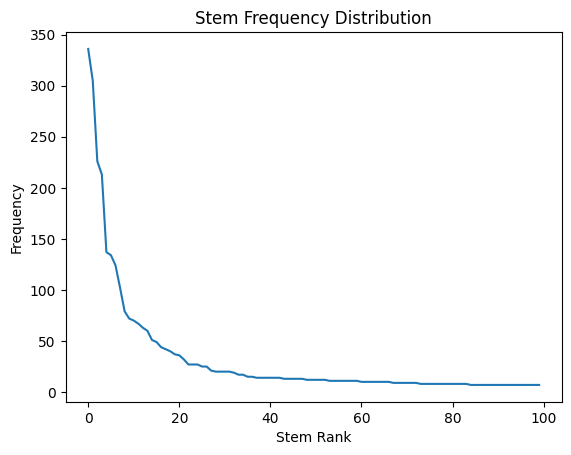

In [103]:
counts = sorted(stem_counts.values(), reverse=True)
plt.plot(counts[:100])
plt.xlabel('Stem Rank')
plt.ylabel('Frequency')
plt.title('Stem Frequency Distribution')
plt.show()